# 01 - Analisis de datos

Objetivo: dejar claro que problema resuelve el proyecto antes de hablar de modelos.

La tarea es multilabel: cada audio puede tener varias etiquetas. Por eso no usamos accuracy; usamos `lwlrap`, la metrica de la competencia Freesound Audio Tagging 2019. Este notebook fija tres cosas para el resto del trabajo: tamano de datos, distribucion de clases y criterio de validacion.


## Imports y configuracion


In [1]:
from pathlib import Path
import sys
from collections import Counter
import contextlib
import wave

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ModuleNotFoundError:
    display = print

ROOT = Path.cwd()
if ROOT.name == '01_analisis_datos':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / '01_analisis_datos' / 'results'
FIG_DIR = RESULTS_DIR / 'figures'
INVESTIGATION = ROOT / 'investigation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(INVESTIGATION))

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
plt.style.use('default')
plt.rcParams.update({
    'figure.figsize': (9, 4.8),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

from scripts.fat2019.data import CORRUPT_OR_BAD_LABEL_FILES, split_labels
from scripts.fat2019.metrics import calculate_overall_lwlrap

curated = pd.read_csv(DATA_DIR / 'train_curated.csv')
noisy = pd.read_csv(DATA_DIR / 'train_noisy.csv')
sample = pd.read_csv(DATA_DIR / 'sample_submission.csv')
label_columns = list(sample.columns[1:])

print(f'ROOT={ROOT}')
print(f'classes in sample_submission: {len(label_columns)}')
print(f'FIG_DIR={FIG_DIR.relative_to(ROOT)}')


ROOT=/home/santig14/fing/taa/2_TallerAA
classes in sample_submission: 80
FIG_DIR=01_analisis_datos/results/figures


## 1. Que datos tenemos

`train_curated.csv` es la fuente limpia para validar decisiones. `train_noisy.csv` existe y es grande, pero no entra por defecto porque las etiquetas son menos confiables; en los experimentos ya se vio que concatenarlo directo degrada fuerte la validacion.


,split,rows,unique_files,mean_labels_per_audio
0,train_curated,4970,4970,1.1573
1,train_noisy,19815,19815,1.2112
2,test/sample_submission,3361,3361,NaN


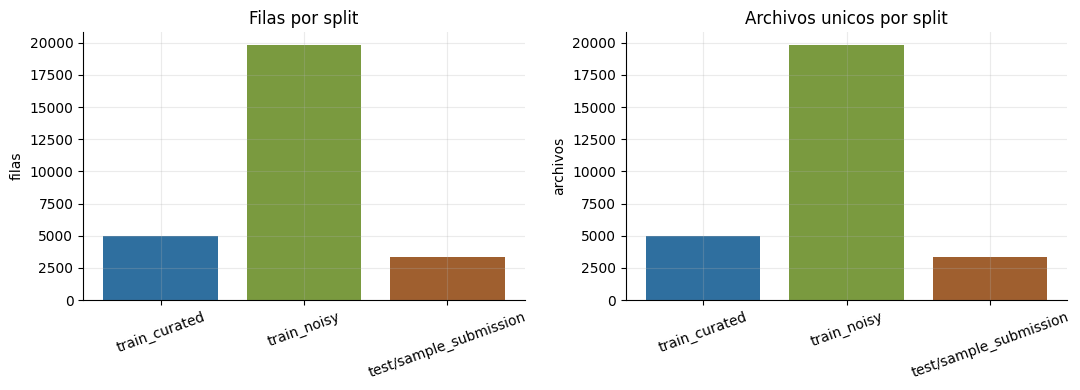

In [2]:
def labels_per_row(df):
    return df['labels'].map(lambda raw: len(split_labels(raw)))

summary = pd.DataFrame([
    {'split': 'train_curated', 'rows': len(curated), 'unique_files': curated['fname'].nunique(), 'mean_labels_per_audio': labels_per_row(curated).mean()},
    {'split': 'train_noisy', 'rows': len(noisy), 'unique_files': noisy['fname'].nunique(), 'mean_labels_per_audio': labels_per_row(noisy).mean()},
    {'split': 'test/sample_submission', 'rows': len(sample), 'unique_files': sample['fname'].nunique(), 'mean_labels_per_audio': np.nan},
])
display(summary.round(4))
summary.to_csv(RESULTS_DIR / 'dataset_split_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(summary['split'], summary['rows'], color=['#2f6f9f', '#7a9a3f', '#9f5f2f'])
axes[0].set_title('Filas por split')
axes[0].set_ylabel('filas')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(summary['split'], summary['unique_files'], color=['#2f6f9f', '#7a9a3f', '#9f5f2f'])
axes[1].set_title('Archivos unicos por split')
axes[1].set_ylabel('archivos')
axes[1].tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / '01_split_sizes.png', dpi=140, bbox_inches='tight')
plt.show()


## 2. Multilabel: cuantas etiquetas tiene cada audio

No es una clasificacion de una sola clase. Muchos audios tienen mas de una etiqueta; por eso el modelo produce 80 probabilidades y la metrica evalua ranking.


,split,mean,median,max
0,curated,1.1573,1.0,6
1,noisy,1.2112,1.0,7


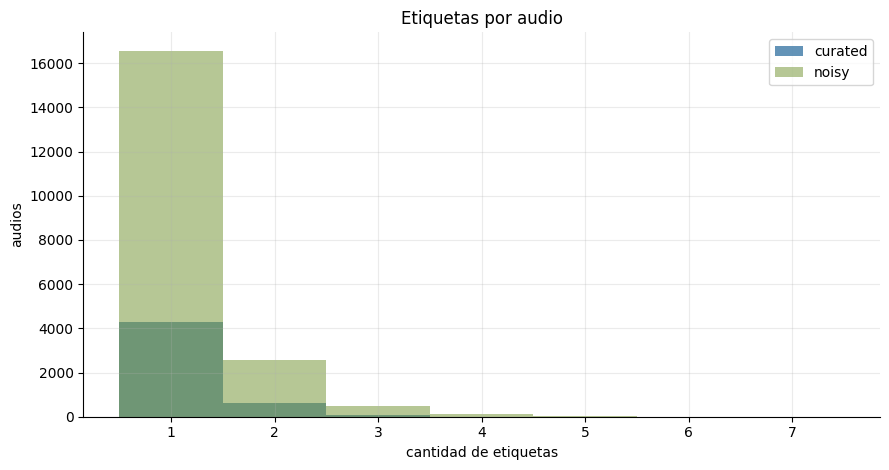

In [3]:
curated_labels_per_row = labels_per_row(curated)
noisy_labels_per_row = labels_per_row(noisy)
labels_per_audio_summary = pd.DataFrame({
    'split': ['curated', 'noisy'],
    'mean': [curated_labels_per_row.mean(), noisy_labels_per_row.mean()],
    'median': [curated_labels_per_row.median(), noisy_labels_per_row.median()],
    'max': [curated_labels_per_row.max(), noisy_labels_per_row.max()],
})
display(labels_per_audio_summary.round(4))
labels_per_audio_summary.to_csv(RESULTS_DIR / 'labels_per_audio_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
bins = np.arange(1, max(curated_labels_per_row.max(), noisy_labels_per_row.max()) + 2) - 0.5
ax.hist(curated_labels_per_row, bins=bins, alpha=0.75, label='curated', color='#2f6f9f')
ax.hist(noisy_labels_per_row, bins=bins, alpha=0.55, label='noisy', color='#7a9a3f')
ax.set_title('Etiquetas por audio')
ax.set_xlabel('cantidad de etiquetas')
ax.set_ylabel('audios')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '02_labels_per_audio_hist.png', dpi=140, bbox_inches='tight')
plt.show()


## 3. Desbalance de clases

El desbalance es fuerte: algunas clases aparecen mucho y otras muy poco. Esto justifica regularizacion, pesos por clase/positivos en entrenamiento y cuidado al leer validacion local.


,curated_count,noisy_count
Accelerating_and_revving_and_vroom,75,300
Acoustic_guitar,75,300
Applause,75,300
Bark,75,300
Bass_guitar,75,300
Bass_drum,75,300
Bathtub_(filling_or_washing),75,300
Burping_and_eructation,75,300
Chewing_and_mastication,75,300
Bus,75,300


,curated_count,noisy_count
Walk_and_footsteps,75,300
Tick-tock,72,300
Bicycle_bell,67,300
Purr,65,300
Frying_(food),63,300
Sneeze,63,300
Sigh,57,300
Glockenspiel,56,300
Buzz,56,300
Race_car_and_auto_racing,56,300


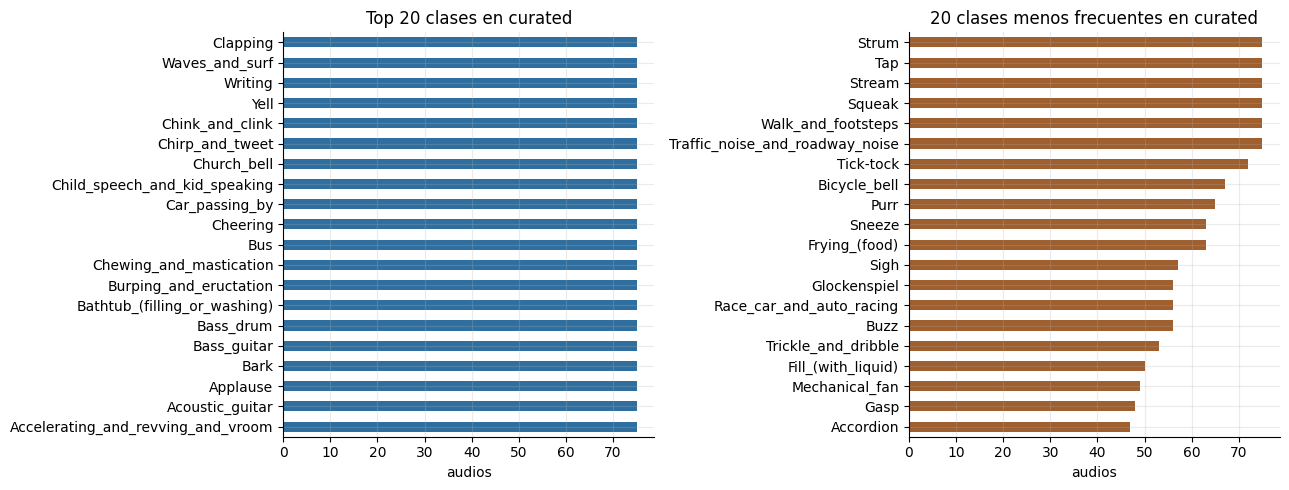

In [4]:
def count_labels(df):
    counts = Counter()
    for raw in df['labels']:
        counts.update(split_labels(raw))
    return pd.Series(counts).sort_values(ascending=False)

curated_counts = count_labels(curated)
noisy_counts = count_labels(noisy)
label_count_table = pd.DataFrame({
    'curated_count': curated_counts,
    'noisy_count': noisy_counts,
}).fillna(0).astype(int).sort_values('curated_count', ascending=False)

display(label_count_table.head(15))
display(label_count_table.tail(15))
label_count_table.to_csv(RESULTS_DIR / 'label_count_table.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
label_count_table.head(20)['curated_count'].sort_values().plot(kind='barh', ax=axes[0], color='#2f6f9f')
axes[0].set_title('Top 20 clases en curated')
axes[0].set_xlabel('audios')

label_count_table.tail(20)['curated_count'].sort_values().plot(kind='barh', ax=axes[1], color='#9f5f2f')
axes[1].set_title('20 clases menos frecuentes en curated')
axes[1].set_xlabel('audios')
fig.tight_layout()
fig.savefig(FIG_DIR / '03_label_frequency_top_rare.png', dpi=140, bbox_inches='tight')
plt.show()


## 4. Curva acumulada de desbalance

Esta vista muestra cuantas etiquetas del dataset quedan explicadas por las clases mas frecuentes. Si pocas clases acumulan mucho peso, un modelo puede parecer bueno prediciendo bien lo frecuente y fallar en clases raras.


,rank,label,count,cumulative_share
0,1,Bark,75,0.0130
1,2,Raindrop,75,0.0261
2,3,Finger_snapping,75,0.0391
3,4,Run,75,0.0522
4,5,Whispering,75,0.0652
5,6,Acoustic_guitar,75,0.0782
6,7,Strum,75,0.0913
7,8,Hi-hat,75,0.1043
8,9,Bass_drum,75,0.1174
9,10,Crowd,75,0.1304


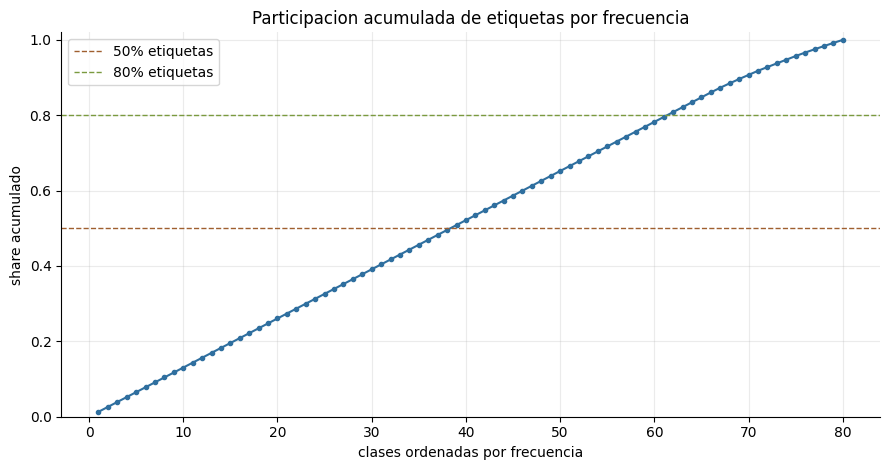

In [5]:
sorted_counts = curated_counts.sort_values(ascending=False)
cumulative = sorted_counts.cumsum() / sorted_counts.sum()
cumulative_df = pd.DataFrame({
    'rank': np.arange(1, len(sorted_counts) + 1),
    'label': sorted_counts.index,
    'count': sorted_counts.values,
    'cumulative_share': cumulative.values,
})
display(cumulative_df.head(15).round(4))
cumulative_df.to_csv(RESULTS_DIR / 'label_cumulative_share.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(cumulative_df['rank'], cumulative_df['cumulative_share'], marker='o', markersize=3, color='#2f6f9f')
ax.axhline(0.5, color='#9f5f2f', linestyle='--', linewidth=1, label='50% etiquetas')
ax.axhline(0.8, color='#7a9a3f', linestyle='--', linewidth=1, label='80% etiquetas')
ax.set_title('Participacion acumulada de etiquetas por frecuencia')
ax.set_xlabel('clases ordenadas por frecuencia')
ax.set_ylabel('share acumulado')
ax.set_ylim(0, 1.02)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '04_label_cumulative_share.png', dpi=140, bbox_inches='tight')
plt.show()


## 5. Duracion de los audios

La duracion es una variable importante: sonidos largos y cortos pueden requerir estrategias distintas de recorte, padding o ventanas temporales. Se lee solo el header WAV, no el audio completo.


,split,count,mean,std,min,5%,25%,50%,75%,95%,max
0,curated,4970.0,7.6477,7.6963,0.30,0.4972,1.6122,4.6759,11.1464,24.4971,57.5712
1,test,3361.0,10.4890,8.2055,0.32,0.8400,3.6200,8.1600,16.1600,27.0000,30.0000


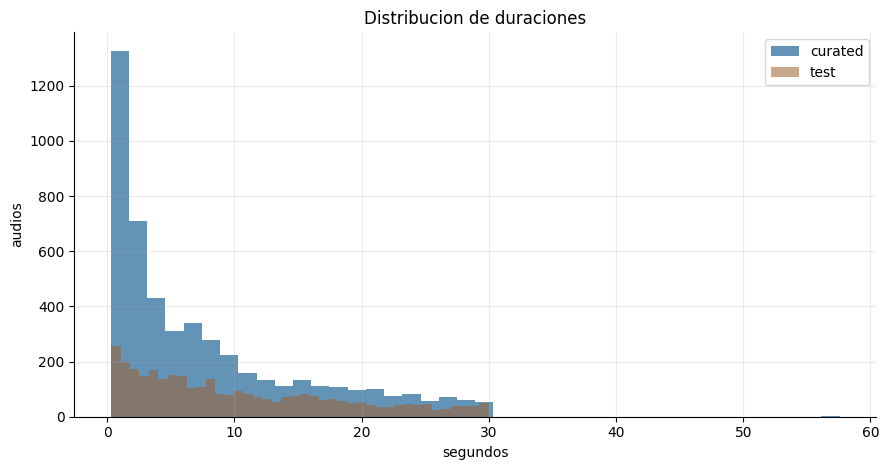

In [6]:
def wav_duration_seconds(path: Path) -> float:
    with contextlib.closing(wave.open(str(path), 'rb')) as wav:
        return wav.getnframes() / float(wav.getframerate())

curated_duration = curated[['fname']].copy()
curated_duration['duration_seconds'] = curated_duration['fname'].map(lambda name: wav_duration_seconds(DATA_DIR / name))

test_duration = sample[['fname']].copy()
test_duration['duration_seconds'] = test_duration['fname'].map(lambda name: wav_duration_seconds(DATA_DIR / name))

duration_summary = pd.DataFrame([
    {'split': 'curated', **curated_duration['duration_seconds'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_dict()},
    {'split': 'test', **test_duration['duration_seconds'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_dict()},
])
display(duration_summary.round(4))
duration_summary.to_csv(RESULTS_DIR / 'duration_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(curated_duration['duration_seconds'], bins=40, alpha=0.75, label='curated', color='#2f6f9f')
ax.hist(test_duration['duration_seconds'], bins=40, alpha=0.55, label='test', color='#9f5f2f')
ax.set_title('Distribucion de duraciones')
ax.set_xlabel('segundos')
ax.set_ylabel('audios')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '05_duration_distribution.png', dpi=140, bbox_inches='tight')
plt.show()


## 6. Por que `lwlrap`

`lwlrap` premia que las clases verdaderas queden arriba en el ranking de probabilidades de cada audio. Esto encaja con multilabel: no necesitamos elegir una sola clase, necesitamos ordenar bien las 80 probabilidades.


,example,lwlrap
0,clases verdaderas arriba,1.000000
1,clases verdaderas abajo,0.388889


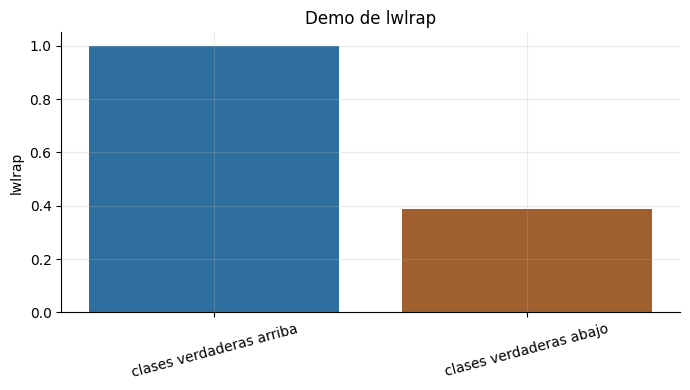

In [7]:
truth = np.array([
    [1, 0, 1, 0],
    [0, 1, 0, 0],
], dtype=float)

good_scores = np.array([
    [0.90, 0.10, 0.80, 0.05],
    [0.20, 0.70, 0.10, 0.05],
])

bad_scores = np.array([
    [0.20, 0.90, 0.10, 0.80],
    [0.80, 0.10, 0.70, 0.05],
])

metric_demo = pd.DataFrame([
    {'example': 'clases verdaderas arriba', 'lwlrap': calculate_overall_lwlrap(truth, good_scores)},
    {'example': 'clases verdaderas abajo', 'lwlrap': calculate_overall_lwlrap(truth, bad_scores)},
])
display(metric_demo)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(metric_demo['example'], metric_demo['lwlrap'], color=['#2f6f9f', '#9f5f2f'])
ax.set_title('Demo de lwlrap')
ax.set_ylabel('lwlrap')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
fig.savefig(FIG_DIR / '06_lwlrap_demo.png', dpi=140, bbox_inches='tight')
plt.show()


## 7. Archivos problematicos

El pipeline de entrenamiento debe excluir o tratar aparte los audios conocidos como corruptos o con etiquetas problematicas. Esto evita que una corrida falle tarde o que aprenda de ejemplos marcados como malos.


In [8]:
bad = sorted(
    set(curated['fname']).intersection(CORRUPT_OR_BAD_LABEL_FILES)
    | set(noisy['fname']).intersection(CORRUPT_OR_BAD_LABEL_FILES)
)
bad_df = pd.DataFrame({'known_bad_or_corrupt_file': bad})
display(bad_df)
bad_df.to_csv(RESULTS_DIR / 'known_bad_files.csv', index=False)


,known_bad_or_corrupt_file
0,1d44b0bd.wav
1,6a1f682a.wav
2,7752cc8a.wav
3,77b925c2.wav
4,c7db12aa.wav
5,f76181c4.wav


## Decisiones que salen de este notebook

- Validacion principal: holdout sobre `train_curated.csv`, semilla fija cuando se comparan modelos.
- Metrica principal: `lwlrap`, no accuracy.
- `train_noisy.csv`: no se concatena directo; solo entra con una estrategia especifica y medida.
- Priors de clase: sirven para probar formato de submission, no como modelo acustico.
- El desbalance de clases debe aparecer en el informe porque condiciona interpretacion de metricas y modelos.
